# Weight Initialization in Neural Networks
Progressive study: zero init -> small random -> Xavier/Glorot -> He init -> comparison.
Each stage is a "commit" documenting what changed and why.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

### commit: dataset — synthesize u-shape dataset
Original used ushape.csv (not available here). If you have it, replace this cell with:
df = pd.read_csv('/content/ushape.csv')

In [3]:
rng = np.random.RandomState(42)
n = 250
theta = rng.uniform(0.2*np.pi, 0.8*np.pi, n)
r0 = rng.normal(1.0, 0.08, n)
class0_x = r0*np.cos(theta)
class0_y = r0*np.sin(theta) - 0.5

class1_x = rng.uniform(-1.2, 1.2, n)
class1_y = rng.normal(-0.9, 0.25, n)

X_raw = np.vstack([
    np.column_stack([class0_x, class0_y]),
    np.column_stack([class1_x, class1_y])
])
y_raw = np.hstack([np.zeros(n), np.ones(n)])

df = pd.DataFrame(X_raw, columns=['X', 'Y'])
df['class'] = y_raw
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [4]:
df.head()

,X,Y,class
0,0.136231,-1.088846,1.0
1,-0.557535,0.324411,0.0
2,-0.829529,-1.043909,1.0
3,0.448331,0.348253,0.0
4,-0.662111,0.185225,0.0


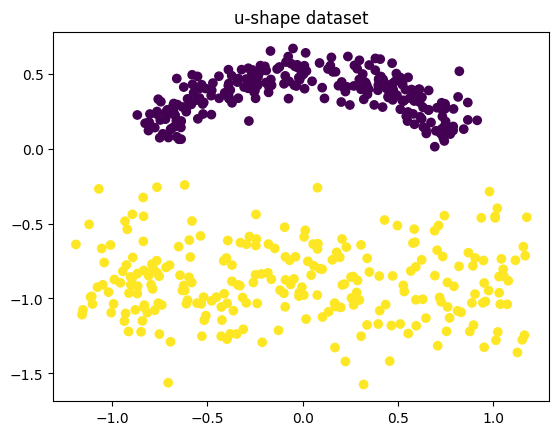

In [5]:
plt.scatter(df['X'], df['Y'], c=df['class'])
plt.title('u-shape dataset')
plt.show()

In [6]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

### commit: infrastructure — reusable train/plot helpers
Same architecture shape, dataset, optimizer, epochs across every experiment.
Only the initializer (and sometimes activation) changes.

In [7]:
def plot_decision_boundary(model, X, y, title):
    from mlxtend.plotting import plot_decision_regions
    plot_decision_regions(X, y.astype('int'), clf=model, legend=2)
    plt.title(title)
    plt.show()

def compile_and_train(model, X, y, epochs=100):
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    history = model.fit(X, y, epochs=epochs, validation_split=0.2, verbose=0)
    return history

histories = {}

###  experiment 1 — zero initialization (sigmoid network)
All weights/biases forced to 0. If every weight in a layer starts identical,
every neuron computes the same output and gets the same gradient during backprop.
Symmetry never breaks, regardless of layer width.

In [8]:
model_zero = Sequential()
model_zero.add(Dense(10, activation='sigmoid', input_dim=2))
model_zero.add(Dense(1, activation='sigmoid'))
model_zero.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
initial_weights = model_zero.get_weights()
initial_weights[0] = np.zeros(model_zero.get_weights()[0].shape)
initial_weights[1] = np.zeros(model_zero.get_weights()[1].shape)
initial_weights[2] = np.zeros(model_zero.get_weights()[2].shape)
initial_weights[3] = np.zeros(model_zero.get_weights()[3].shape)
model_zero.set_weights(initial_weights)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


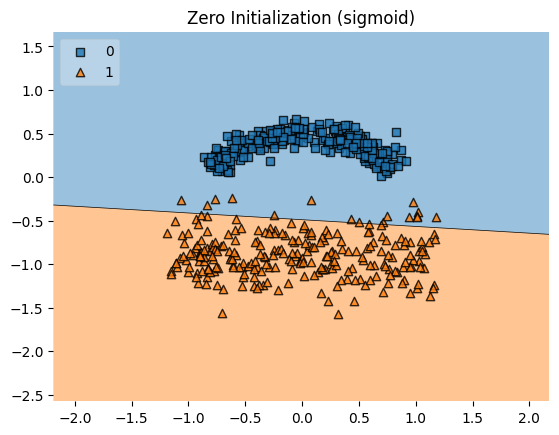

In [10]:
histories['zero_init'] = compile_and_train(model_zero, X, y)
plot_decision_boundary(model_zero, X, y, 'Zero Initialization (sigmoid)')

###  findings — zero init confirms the symmetry problem
Check the first hidden layer's weight columns — they should still be (near-)identical
after training, proving the 10 neurons never differentiated.

In [11]:
w1 = model_zero.get_weights()[0]  # shape (2, 10)
print("Are all neuron columns identical after training?",
      np.allclose(w1, w1[:, [0]], atol=1e-6))
print(w1)

Are all neuron columns identical after training? True
[[0.1465002 0.1465002 0.1465002 0.1465002 0.1465002 0.1465002 0.1465002
  0.1465002 0.1465002 0.1465002]
 [1.8971344 1.8971344 1.8971344 1.8971344 1.8971344 1.8971344 1.8971344
  1.8971344 1.8971344 1.8971344]]


###  experiment 2 — small random initialization (sigmoid network)
Weights ~ N(0,1)*0.01. Breaks symmetry, but pre-activations stay near 0,
so signal magnitude shrinks layer after layer -> vanishing gradients from scale alone.

In [12]:
model_small = Sequential()
model_small.add(Dense(10, activation='sigmoid', input_dim=2))
model_small.add(Dense(1, activation='sigmoid'))

w = model_small.get_weights()
w[0] = np.random.randn(2, 10) * 0.01
w[2] = np.random.randn(10, 1) * 0.01
model_small.set_weights(w)

print("min weight:", (np.random.randn(10, 10) * 0.01).min())
print("max weight:", (np.random.randn(10, 10) * 0.01).max())

min weight: -0.02906689335601616
max weight: 0.02204628731290424


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


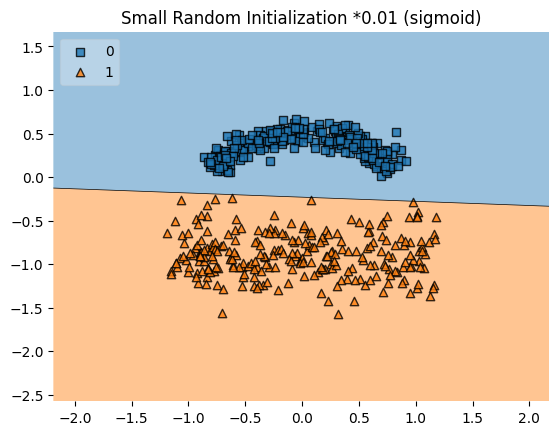

In [13]:
histories['small_random'] = compile_and_train(model_small, X, y)
plot_decision_boundary(model_small, X, y, 'Small Random Initialization *0.01 (sigmoid)')

###  experiment 3 — Xavier / Glorot initialization (sigmoid network)
Designed for near-linear activations (sigmoid, tanh). Keeps activation/gradient
variance roughly constant across layers.

fan_in = inputs to layer, fan_out = outputs of layer.

Xavier Normal:  W ~ N(0, sigma^2), sigma = sqrt(2 / (fan_in + fan_out))
Xavier Uniform: W ~ U(-limit, limit), limit = sqrt(6 / (fan_in + fan_out))

In [14]:
def xavier_normal(fan_in, fan_out):
    std = np.sqrt(2 / (fan_in + fan_out))
    return np.random.randn(fan_in, fan_out) * std

def xavier_uniform(fan_in, fan_out):
    limit = np.sqrt(6 / (fan_in + fan_out))
    return np.random.uniform(-limit, limit, size=(fan_in, fan_out))

### experiment 3a — Xavier Normal via manual weight injection

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


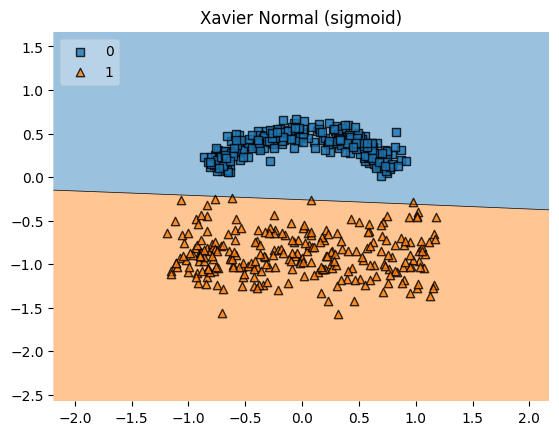

In [15]:
model_xavier_n = Sequential()
model_xavier_n.add(Dense(10, activation='sigmoid', input_dim=2))
model_xavier_n.add(Dense(1, activation='sigmoid'))

w = model_xavier_n.get_weights()
w[0] = xavier_normal(2, 10)
w[2] = xavier_normal(10, 1)
model_xavier_n.set_weights(w)

histories['xavier_normal'] = compile_and_train(model_xavier_n, X, y)
plot_decision_boundary(model_xavier_n, X, y, 'Xavier Normal (sigmoid)')

###  experiment 3b — Xavier Uniform via manual weight injection

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


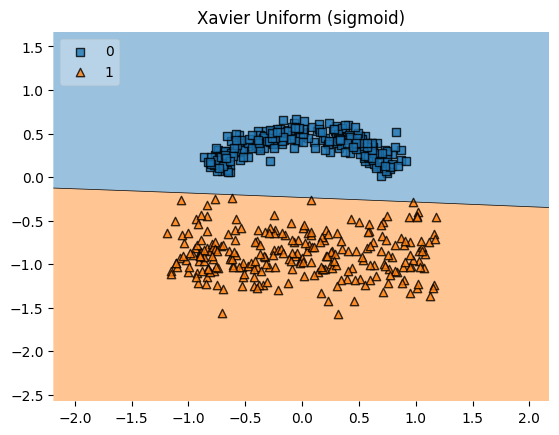

In [16]:
model_xavier_u = Sequential()
model_xavier_u.add(Dense(10, activation='sigmoid', input_dim=2))
model_xavier_u.add(Dense(1, activation='sigmoid'))

w = model_xavier_u.get_weights()
w[0] = xavier_uniform(2, 10)
w[2] = xavier_uniform(10, 1)
model_xavier_u.set_weights(w)

histories['xavier_uniform'] = compile_and_train(model_xavier_u, X, y)
plot_decision_boundary(model_xavier_u, X, y, 'Xavier Uniform (sigmoid)')

###  experiment 3c — Xavier via Keras built-in initializers
Same formulae, exposed directly through kernel_initializer.

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


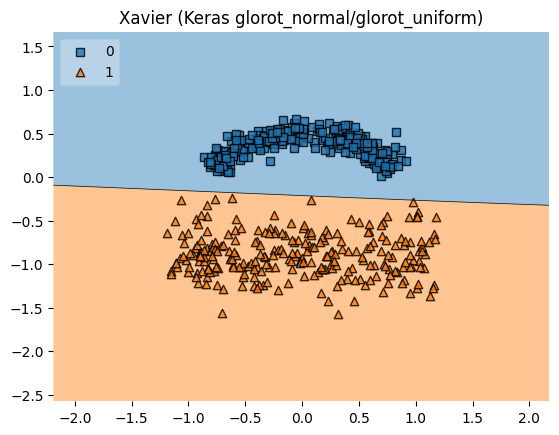

In [17]:
model_xavier_keras = Sequential()
model_xavier_keras.add(Dense(10, activation='sigmoid', input_dim=2, kernel_initializer='glorot_normal'))
model_xavier_keras.add(Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform'))

histories['xavier_keras'] = compile_and_train(model_xavier_keras, X, y)
plot_decision_boundary(model_xavier_keras, X, y, 'Xavier (Keras glorot_normal/glorot_uniform)')

###  findings — Xavier on the sigmoid network
Both Xavier variants should converge faster and trace the U-boundary more cleanly than
zero_init/small_random — variance is calibrated to fan_in/fan_out, not arbitrary.

###  experiment 4 — He initialization (ReLU network)
ReLU zeroes ~half its inputs, halving forward variance. Xavier under-provisions for this.
He doubles the variance relative to Xavier's fan_in term.

He Normal:  W ~ N(0, sigma^2), sigma = sqrt(2 / fan_in)
He Uniform: W ~ U(-limit, limit), limit = sqrt(6 / fan_in)

Mirrors the deeper 4-hidden-layer ReLU network from the original notebook.

In [18]:
def he_normal(fan_in, fan_out):
    std = np.sqrt(2 / fan_in)
    return np.random.randn(fan_in, fan_out) * std

In [19]:
model_he = Sequential()
model_he.add(Dense(10, activation='relu', input_dim=2, kernel_initializer='he_normal'))
model_he.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model_he.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model_he.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model_he.add(Dense(1, activation='sigmoid'))
model_he.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
w = model_he.get_weights()
w[0] = he_normal(2, 10)
w[2] = he_normal(10, 10)
w[4] = he_normal(10, 10)
w[6] = he_normal(10, 10)
model_he.set_weights(w)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


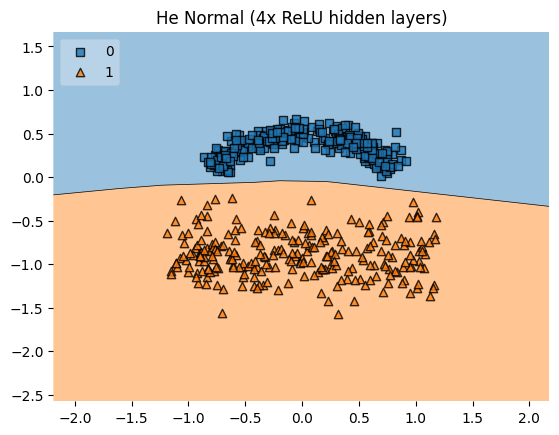

In [21]:
histories['he_normal'] = compile_and_train(model_he, X, y)
plot_decision_boundary(model_he, X, y, 'He Normal (4x ReLU hidden layers)')

###  findings — He on the deep ReLU network
He lets the 4-hidden-layer ReLU net train stably — corrects the variance collapse
Xavier would cause deeper into a ReLU stack.

###  comparison — all strategies side by side

| Strategy | Formula | Best paired with | Fixes | Still vulnerable to |
|---|---|---|---|---|
| Zero | W = 0 | none | — | Total symmetry, never breaks |
| Small random | N(0,1)*0.01 | none | Breaks symmetry | Vanishing signal in deep/sigmoid nets |
| Xavier/Glorot | sigma=sqrt(2/(fan_in+fan_out)) | sigmoid, tanh | Variance drift across layers | Under-provisions for ReLU |
| He | sigma=sqrt(2/fan_in) | ReLU | ReLU's variance-halving | Not tuned for sigmoid/tanh |

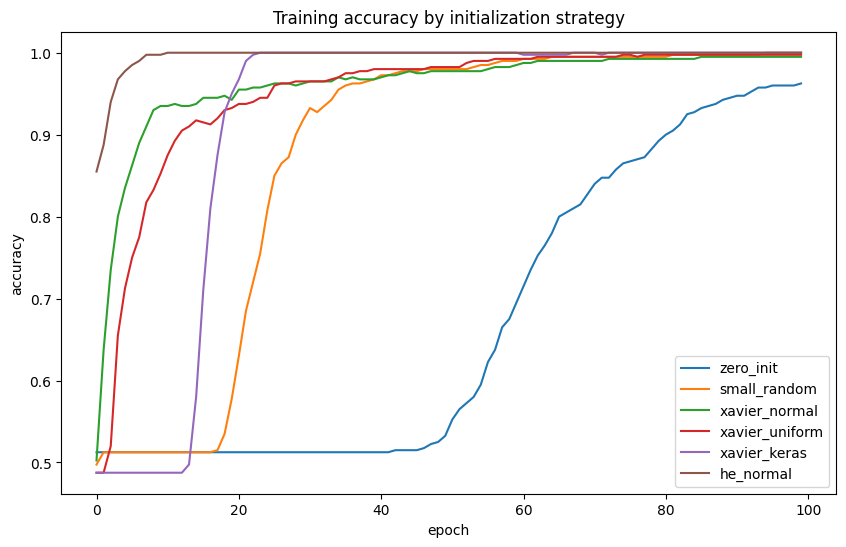

In [22]:
plt.figure(figsize=(10, 6))
for name, h in histories.items():
    plt.plot(h.history['accuracy'], label=name)
plt.title('Training accuracy by initialization strategy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

###  conclusion
- Zero init: never viable, permanent symmetry.
- Small random: breaks symmetry but leaves signal scale to chance.
- Xavier/Glorot: variance calibrated to fan_in+fan_out, matches sigmoid/tanh.
- He: re-derives that variance target for ReLU's asymmetric zeroing behavior.

The initializer is chosen to match the activation function's statistical behavior,
not picked arbitrarily.